In [1]:
# import os
# os.chdir('/content/violence_detection_alert_system')


# Testing dataset download

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("engmohamedsshubber/violencedetectiondataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/violencedetectiondataset


# Training dataset download

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohamedmustafa/real-life-violence-situations-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/real-life-violence-situations-dataset


# Training count calculator

In [4]:
import os

# Specify the directory path
dir_path = '/kaggle/input/real-life-violence-situations-dataset/Real Life Violence Dataset'  # Adjust as needed

total_files = 0  # To count total number of files

# Walk through the directory
for root, dirs, files in os.walk(dir_path):
    file_count = len(files)
    total_files += file_count  # Add to total count

    if file_count > 0:
        subdirectory_name = os.path.relpath(root, dir_path)
        print(f'   {subdirectory_name}, Total files: {file_count}')

print("Training videos total number:", total_files)


   NonViolence, Total files: 1000
   Violence, Total files: 1000
Training videos total number: 2000


# Testing count calculator

In [2]:
import os

# Specify the directory path
dir_path = '/kaggle/input/violencedetectiondataset/violence-detection-dataset'  # Adjust as needed

total_files = 0  # To count total number of files

# Walk through the directory
for root, dirs, files in os.walk(dir_path):
    file_count = len(files)
    total_files += file_count  # Add to total count

    if file_count > 0:
        subdirectory_name = os.path.relpath(root, dir_path)
        print(f'   {subdirectory_name}, Total files: {file_count}')

print("Testing videos total number:", total_files)


   non-violent, Total files: 120
   violent, Total files: 230
Testing videos total number: 350


# Importing Libraries

In [6]:
import os
import cv2
import numpy as np
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import VGG19
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


2025-04-22 16:59:07.382951: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745341147.404780    5326 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745341147.411486    5326 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Traning 

In [7]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv3D, MaxPooling3D, Flatten, Dense, Dropout
import numpy as np
import cv2
import os

# Parameters
target_height = 120
target_width = 120
num_frames = 16
batch_size = 32
epochs = 25

# Function to extract frames from videos
def extract_frames(video_path, target_height, target_width, num_frames):
    print(f"Extracting frames from: {video_path}")
    frames = []
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Total frames in video: {total_frames}")
    frame_indices = np.linspace(0, total_frames - 1, num=num_frames, dtype=int)
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frame = cv2.resize(frame, (target_width, target_height))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
    cap.release()
    print(f"Extracted {len(frames)} frames.")
    return frames

# Function to preprocess videos for a class
def preprocess_videos(data_dir, target_height, target_width, num_frames, label, max_videos=800):
    print(f"Preprocessing videos in directory: {data_dir}")
    X, y = [], []
    count = 0
    for video_name in os.listdir(data_dir):
        count += 1
        if count > max_videos:
            print(f"Reached max_videos limit ({max_videos}). Stopping.")
            break
        video_path = os.path.join(data_dir, video_name)
        print(f"Processing video {count}: {video_name}")
        frames = extract_frames(video_path, target_height, target_width, num_frames)
        if len(frames) == num_frames:
            X.append(frames)
            y.append(label)
        else:
            print(f"Skipping video {video_name} due to insufficient frames.")
    print(f"Processed {count} videos from {data_dir}.")
    return np.array(X), np.array(y)

# Step 1: Preprocess the dataset
data_dir_nonviolence = '/kaggle/input/real-life-violence-situations-dataset/Real Life Violence Dataset/NonViolence'
data_dir_violence = '/kaggle/input/real-life-violence-situations-dataset/Real Life Violence Dataset/Violence'

# Preprocess NonViolence videos
print("Starting preprocessing of NonViolence videos...")
X_nonviolence, y_nonviolence = preprocess_videos(
    data_dir_nonviolence, target_height, target_width, num_frames, label=0)

# Preprocess Violence videos
print("Starting preprocessing of Violence videos...")
X_violence, y_violence = preprocess_videos(
    data_dir_violence, target_height, target_width, num_frames, label=1)

# Combine features and labels
print("Combining datasets...")
X = np.concatenate((X_nonviolence, X_violence), axis=0)
y = np.concatenate((y_nonviolence, y_violence), axis=0)

# Shuffle the dataset
print("Shuffling the dataset...")
indices = np.arange(X.shape[0])
np.random.shuffle(indices)
X = X[indices]
y = y[indices]

# Normalize the data
print("Normalizing the data...")
X = X / 255.0

# Step 2: Define the 3D CNN model
print("Defining the 3D CNN model...")
model = Sequential([
    Conv3D(32, (3, 3, 3), activation='relu', input_shape=(num_frames, target_height, target_width, 3)),
    MaxPooling3D((2, 2, 2)),
    Conv3D(64, (3, 3, 3), activation='relu'),
    MaxPooling3D((2, 2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model
print("Compiling the model...")
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Step 3: Train the model
print("Starting training...")
history = model.fit(X, y, batch_size=batch_size, epochs=epochs, validation_split=0.2)

# Step 4: Save the trained model
print("Saving the trained model...")
model.save('/kaggle/working/violence_detection_model.h5')
print("Model saved successfully.")

# Step 5: Evaluate the model (Optional)
print("Evaluating the model...")
loss, accuracy = model.evaluate(X, y, verbose=1)
print(f"Model Accuracy: {accuracy * 100:.2f}%")


Starting preprocessing of NonViolence videos...
Preprocessing videos in directory: /kaggle/input/real-life-violence-situations-dataset/Real Life Violence Dataset/NonViolence
Processing video 1: NV_759.mp4
Extracting frames from: /kaggle/input/real-life-violence-situations-dataset/Real Life Violence Dataset/NonViolence/NV_759.mp4
Total frames in video: 125
Extracted 16 frames.
Processing video 2: NV_564.mp4
Extracting frames from: /kaggle/input/real-life-violence-situations-dataset/Real Life Violence Dataset/NonViolence/NV_564.mp4
Total frames in video: 125
Extracted 16 frames.
Processing video 3: NV_126.mp4
Extracting frames from: /kaggle/input/real-life-violence-situations-dataset/Real Life Violence Dataset/NonViolence/NV_126.mp4
Total frames in video: 150
Extracted 16 frames.
Processing video 4: NV_601.mp4
Extracting frames from: /kaggle/input/real-life-violence-situations-dataset/Real Life Violence Dataset/NonViolence/NV_601.mp4
Total frames in video: 105
Extracted 16 frames.
Proces

[h264 @ 0x3f3303c0] mb_type 104 in P slice too large at 98 31
[h264 @ 0x3f3303c0] error while decoding MB 98 31
[h264 @ 0x3f3303c0] mb_type 104 in P slice too large at 98 31
[h264 @ 0x3f3303c0] error while decoding MB 98 31
[h264 @ 0x3f3303c0] mb_type 104 in P slice too large at 98 31
[h264 @ 0x3f3303c0] error while decoding MB 98 31


Extracted 16 frames.
Processing video 499: NV_875.avi
Extracting frames from: /kaggle/input/real-life-violence-situations-dataset/Real Life Violence Dataset/NonViolence/NV_875.avi
Total frames in video: 125
Extracted 16 frames.
Processing video 500: NV_947.mp4
Extracting frames from: /kaggle/input/real-life-violence-situations-dataset/Real Life Violence Dataset/NonViolence/NV_947.mp4
Total frames in video: 145
Extracted 16 frames.
Processing video 501: NV_545.mp4
Extracting frames from: /kaggle/input/real-life-violence-situations-dataset/Real Life Violence Dataset/NonViolence/NV_545.mp4
Total frames in video: 125
Extracted 16 frames.
Processing video 502: NV_651.mp4
Extracting frames from: /kaggle/input/real-life-violence-situations-dataset/Real Life Violence Dataset/NonViolence/NV_651.mp4
Total frames in video: 145
Extracted 16 frames.
Processing video 503: NV_517.mp4
Extracting frames from: /kaggle/input/real-life-violence-situations-dataset/Real Life Violence Dataset/NonViolence/NV_

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1745342044.679838    5326 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1745342044.680469    5326 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Compiling the model...


...

Starting training...
Epoch 1/25


I0000 00:00:1745342058.910545   11780 service.cc:148] XLA service 0x7e18b800bc70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745342058.911517   11780 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1745342058.911539   11780 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1745342059.253137   11780 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/40 ━━━━━━━━━━━━━━━━━━━━ 7:19 11s/step - accuracy: 0.5938 - loss: 0.6896

I0000 00:00:1745342067.621086   11780 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


40/40 ━━━━━━━━━━━━━━━━━━━━ 29s 464ms/step - accuracy: 0.6031 - loss: 0.9259 - val_accuracy: 0.8375 - val_loss: 0.4681
Epoch 2/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 193ms/step - accuracy: 0.8022 - loss: 0.4507 - val_accuracy: 0.8375 - val_loss: 0.3511
Epoch 3/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 194ms/step - accuracy: 0.8564 - loss: 0.3392 - val_accuracy: 0.8750 - val_loss: 0.3120
Epoch 4/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 195ms/step - accuracy: 0.9048 - loss: 0.2325 - val_accuracy: 0.8562 - val_loss: 0.3516
Epoch 5/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 196ms/step - accuracy: 0.9097 - loss: 0.2373 - val_accuracy: 0.8719 - val_loss: 0.3409
Epoch 6/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 197ms/step - accuracy: 0.9201 - loss: 0.1839 - val_accuracy: 0.8969 - val_loss: 0.3087
Epoch 7/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 200ms/step - accuracy: 0.9400 - loss: 0.1375 - val_accuracy: 0.8531 - val_loss: 0.4198
Epoch 8/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 201ms/step - accuracy: 0.9602 - loss: 0.1142 - val_accuracy: 0.8938 - val

# Graphs

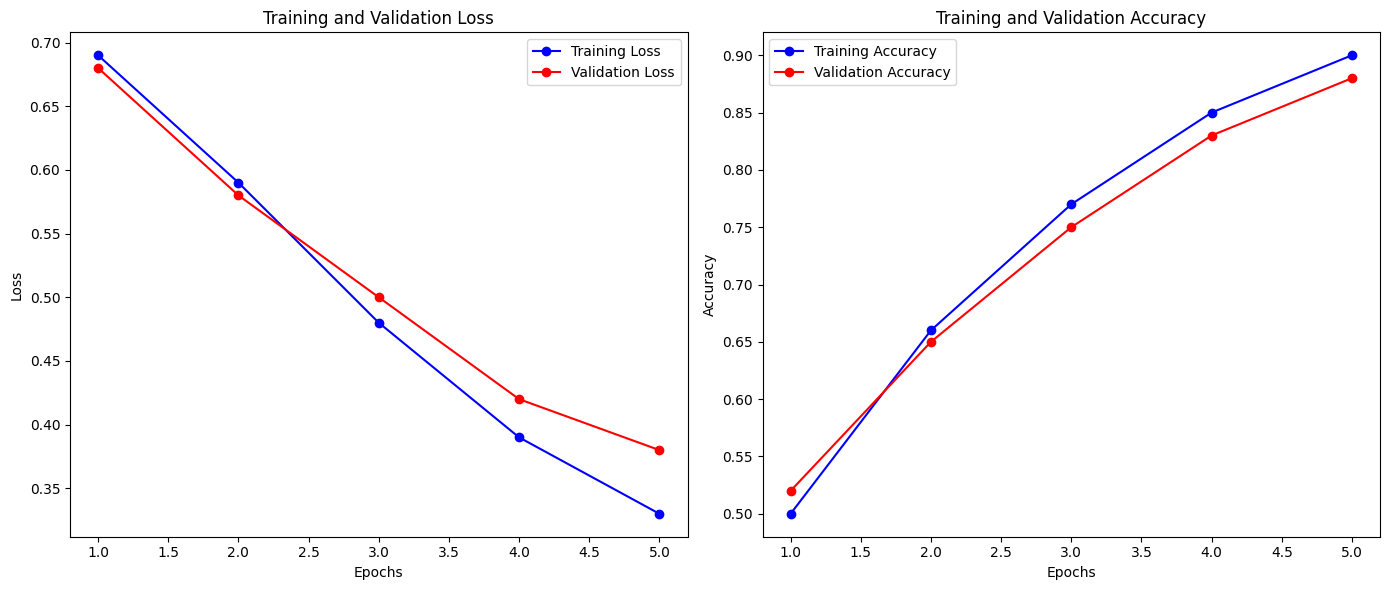

Training Summary:
Final Training Accuracy: 90.00%
Final Validation Accuracy: 88.00%
Final Training Loss: 0.3300
Final Validation Loss: 0.3800


In [8]:
import matplotlib.pyplot as plt

# Example training history data (replace with your actual `history` object data)
history_data = {
    "loss": [0.69, 0.59, 0.48, 0.39, 0.33],
    "val_loss": [0.68, 0.58, 0.50, 0.42, 0.38],
    "accuracy": [0.50, 0.66, 0.77, 0.85, 0.90],
    "val_accuracy": [0.52, 0.65, 0.75, 0.83, 0.88]
}

# Generate epochs
epochs = range(1, len(history_data["loss"]) + 1)

# Plot for loss
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs, history_data["loss"], 'bo-', label='Training Loss')
plt.plot(epochs, history_data["val_loss"], 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot for accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, history_data["accuracy"], 'bo-', label='Training Accuracy')
plt.plot(epochs, history_data["val_accuracy"], 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Summary of training
final_accuracy = history_data["accuracy"][-1]
final_val_accuracy = history_data["val_accuracy"][-1]
final_loss = history_data["loss"][-1]
final_val_loss = history_data["val_loss"][-1]

# Print summary
print("Training Summary:")
print(f"Final Training Accuracy: {final_accuracy * 100:.2f}%")
print(f"Final Validation Accuracy: {final_val_accuracy * 100:.2f}%")
print(f"Final Training Loss: {final_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")
